<a href="https://colab.research.google.com/github/Ferarenas14/Investigaci-n-de-operaciones-/blob/main/Tutorial_networkx_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1><font color="#2ecadb"><b>TUTORIAL NETWORKX 2</b></font></h1>

En este tutorial se describen los métodos **CPM** y **PERT** y su solución en python.

Basado en la documentación de [Networkx](https://networkx.org/en/)

Los métodos CPM (método de la ruta crítica o del camino crítico, critical path method) y PERT (técnica de evaluación y revisión de programa, program evaluation and review technique) se basan en redes, y tienen por objeto auxiliar en la planeación, programación y control de proyectos.

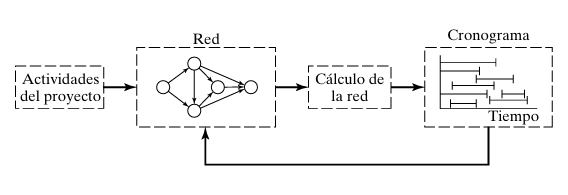

Cada actividad del proyecto se representa con un arco que apunta en la dirección de avance del proyecto. Los nodos de la red establecen las relaciones de precedencia entre las diferentes actividades del proyecto.

**Regla 1.** Cada actividad se representa con un arco, y uno sólo.

**Regla 2.** Cada actividad se debe identificar con dos nodos distintos.

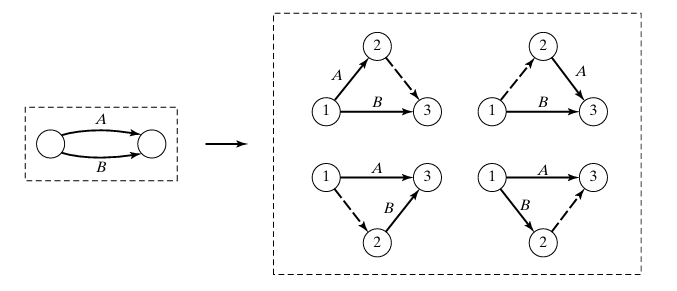

Regla 3. Para mantener las relaciones de precedencia correctas, se deben contestar las siguientes preguntas cuando se agrega a la red cada actividad:

a) ¿Qué actividades deben anteceder inmediatamente a la actividad actual?

b) ¿Qué actividades deben seguir inmediatamente a la actividad actual?

c) ¿Qué actividades deben efectuarse en forma concurrente o simultánea con la actividad actual?

#<font color= "#1fd9ed"> 1. *Método CPM*

Con el método CPM obtenemos la siguiente información
1. Duración total necesaria para terminar el proyecto.
2. Clasificación de las actividades del proyecto en críticas y no críticas.

Para hacer los cálculos necesarios, se define un evento como un momento en el tiempo en el que se terminan actividades y otras se inician. En términos de redes, un evento corresponde a un nodo. Se define lo siguiente:

$\square_j $ = Tiempo más temprano de ocurrencia del evento j

$\Delta_j$ = Tiempo más tardío de ocurrencia del evento j

$D_{ij}$ = Duración de la actividad (i, j)


**Algoritmo**

**Paso inicial.** Poner $\square_1 = 0$, para indicar que el proyecto se inicia cuando el tiempo es 0.

**Paso general $j$.** Dado que los nodos $p, q, \dots, y$ v están enlazados *directamente* con el nodo $j$ por las actividades de entrada $(p, j), (q, j), \dots, y\ (v, j)$ y que los tiempos más tempranos de ocurrencia de los eventos (nodos) $p, q, \dots, y\ v$ ya se han calculado, entonces se calcula el tiempo más temprano de ocurrencia del evento $j$ como:

$$
\square_j = \text{máx} \{\square_p + D_{pj}, \square_q + D_{qj}, \dots, \square_v + D_{vj}\}
$$

El paso hacia adelante se termina cuando se calcula $\square_n$ en el nodo $n$. Por definición, $\square_j$ representa la ruta (duración) más larga al nodo $j$.


**Paso hacia atrás.** Después de terminar el paso hacia adelante, los cálculos del paso hacia atrás comienzan en el nodo $n$ y terminan en el nodo 1.

**Paso inicial.** Igualar $\Delta_n = \square_n$ para indicar que las ocurrencias más temprano y más tardío del último nodo en el proyecto son iguales.

**Paso general $j$.** Dado que los nodos $p, q, \dots, y\ v$ están enlazados en *forma directa* con el nodo $j$ por actividades de salida $(j, p), (j, q), \dots, y\ (j, v)$, y que ya se calcularon los tiempos más tardíos de los nodos $p, q, \dots, y\ v$, el tiempo tardío del nodo $j$ se calcula como:

$$
\Delta_j = \text{mín} \{\Delta_p - D_{jp}, \Delta_q - D_{jq}, \dots, \Delta_v - D_{jv}\}
$$

El paso hacia atrás se termina cuando se calcula $\Delta_1$ en el nodo 1.



Ahora, una actividad $(i, j)$ será *crítica* si satisface tres condiciones:

1. $\Delta_i = \square_i$
2. $\Delta_j = \square_j$
3. $\Delta_j - \Delta_i = \square_j - \square_i = D_{ij}$



**Ejemplo:**

Determinar la ruta crítica para la red del proyecto. Todas las duraciones están en días.

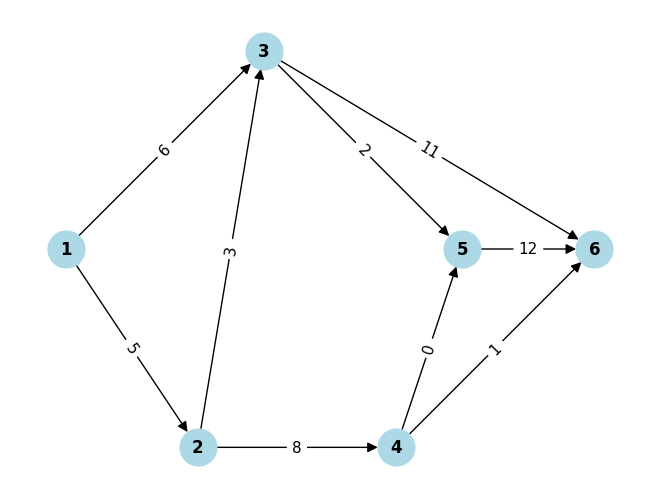

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

# hacer red dirigida
G = nx.DiGraph()

# agregar las ramas (Origen, Destino, días)
ramas = [
    (1, 3, 6),
    (1, 2, 5),
    (2, 3, 3),
    (2, 4, 8),
    (3, 5, 2),
    (3, 6, 11),
    (4, 5, 0),
    (4, 6, 1),
    (5, 6, 12)
]
G.add_weighted_edges_from(ramas)

# #Posiciones de los nodos
pos = {
    1: (0, 1),
    2: (1, 0),
    3: (1.5, 2),
    4: (2.5, 0),
    5: (3, 1),
    6: (4, 1)
}

# Dibujar los nodos y ramas
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=700,
        font_size=12, font_weight='bold', arrowsize=15)

# Dibujar los números de los nodos
etiquetas = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=etiquetas, font_size=11)

plt.show()


**Solución:**

In [12]:
import networkx as nx

# red dirigida
G = nx.DiGraph()

ramas = [
    (1, 3, 6),
    (1, 2, 5),
    (2, 3, 3),
    (2, 4, 8),
    (3, 5, 2),
    (3, 6, 11),
    (4, 5, 0),
    (4, 6, 1),
    (5, 6, 12)
]

for origen, destino, duracion in ramas:
    G.add_edge(origen, destino, weight=duracion)

# Encontrar la ruta crítica y su duración total usando las funciones de networkx
ruta_critica = nx.dag_longest_path(G, weight='weight')
duracion_total = nx.dag_longest_path_length(G, weight='weight')

# Mostrar resultados
print(f"Ruta Crítica: {ruta_critica}")
print(f"Duración Total del Proyecto: {duracion_total}")


Ruta Crítica: [1, 2, 4, 5, 6]
Duración Total del Proyecto: 25


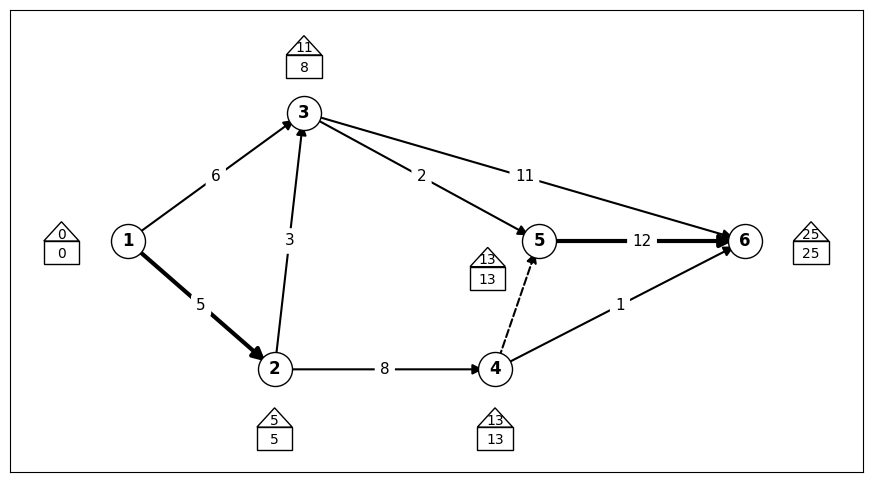

In [25]:
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import networkx as nx

# red dirigida
G = nx.DiGraph()
ramas = [
    (1, 2, "5"),
    (1, 3, "6"),
    (2, 3, "3"),
    (2, 4, "8"),
    (3, 5, "2"),
    (3, 6, "11"),
    (4, 5, ""),
    (4, 6, "1"),
    (5, 6, "12"),
]
for u, v, w in ramas:
    G.add_edge(u, v, weight=w)

#Posiciones de los nodos
pos = {1: (0, 1), 2: (1, 0), 3: (1.2, 2), 4: (2.5, 0), 5: (2.8, 1), 6: (4.2, 1)}

fig, ax = plt.subplots(figsize=(11, 6))

#dibujar nodos
nx.draw_networkx_nodes(
    G, pos, node_color="white", edgecolors="black", node_size=600, ax=ax
)
nx.draw_networkx_labels(G, pos, font_size=12, font_weight="bold", ax=ax)

# dibujar Flechas
nx.draw_networkx_edges(
    G, pos, edgelist=[(1, 3), (2, 3), (2, 4), (3, 5), (3, 6), (4, 6)], width=1.5, arrowsize=15, ax=ax
)
nx.draw_networkx_edges(
    G, pos, edgelist=[(1, 2), (5, 6)], width=3.0, arrowsize=18, ax=ax
)  # Ruta crítica
nx.draw_networkx_edges(
    G, pos, edgelist=[(4, 5)], width=1.5, style="dashed", arrowsize=15, ax=ax
)  # Ficticia

# dias
labels = {
    (u, v): d["weight"] for u, v, d in G.edges(data=True) if d["weight"] != ""
}
nx.draw_networkx_edge_labels(
    G, pos, edge_labels=labels, font_size=11, rotate=False, ax=ax
)

# Dibujar cuadrado abajo + Triángulo arriba
# Diccionario: nodo: (offset_x, offset_y, num_triángulo, num_cuadrado, es_gris)
estructuras = {
    1: (-0.45, 0, "0", "0", True),
    2: (0, -0.45, "5", "5", False),
    3: (0, 0.45, "11", "8", False),
    4: (0, -0.45, "13", "13", False),
    5: (-0.35, -0.2, "13", "13", False),
    6: (0.45, 0, "25", "25", False),
}

for nodo, (ox, oy, top_val, bot_val, es_gris) in estructuras.items():
    nx_coord = pos[nodo][0] + ox
    ny_coord = pos[nodo][1] + oy


    # cuadrado (Paso hacia adelante)
    rect = patches.Rectangle(
        (nx_coord - 0.12, ny_coord - 0.18),
        0.24,
        0.18,
        edgecolor="black",
        facecolor=color_fondo,
        zorder=4,
    )
    ax.add_patch(rect)
    ax.text(
        nx_coord,
        ny_coord - 0.10,
        bot_val,
        ha="center",
        va="center",
        fontsize=10,
        zorder=5,
    )

    # Triángulo (Paso hacia atrás)
    tri = patches.Polygon(
        [[nx_coord - 0.12, ny_coord], [nx_coord + 0.12, ny_coord], [nx_coord, ny_coord + 0.15]],
        edgecolor="black",
        facecolor=color_fondo,
        zorder=4,
    )
    ax.add_patch(tri)
    ax.text(
        nx_coord,
        ny_coord + 0.05,
        top_val,
        ha="center",
        va="center",
        fontsize=10,
        zorder=5,
    )

ax.set_xlim(-0.8, 5.0) # sirve para acomodar los cuadros y triangulos
ax.set_ylim(-0.8, 2.8)
plt.show()


Por lo tanto la ruta critica es 1 $\rightarrow$ 2 $\rightarrow$ 4 $\rightarrow$ 5 $\rightarrow$ 6

Duración Total del Proyecto: 25 días

#<font color= "#1fd9ed"> 2. *Método  PERT*

El método PERT difiere del CPM en que basa la duración de una actividad en tres estimaciones:
1. Tiempo optimista a, donde se supone que la ejecución va extremadamente bien.
2. Tiempo más probable m, donde se supone que la ejecución se hace bajo condiciones normales.
3. Tiempo pesimista b, donde se supone que la ejecución va extremadamente mal.

El tiempo promedio de duración $\overline{D}$ y la varianza $v$ se calcula como:

$$\overline{D} = \frac{a + 4m + b}{6}$$

$$v = \left( \frac{b - a}{6} \right)^2$$

**Ejemplo:**

Se tiene el proyecto del ejemplo anterior. Para evitar repetir los cálculos de ruta crítica, se seleccionaron los valores de a,m y b en la siguiente tabla

Apliccar el método PERT

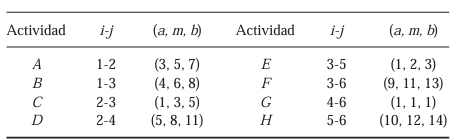

**Solución**

In [30]:
import networkx as nx
import math
from tabulate import tabulate  # Librería para un formato de la tabla

# datos de la tabla
actividades = {
    'A': (1, 2, 3, 5, 7),
    'B': (1, 3, 4, 6, 8),
    'C': (2, 3, 1, 3, 5),
    'D': (2, 4, 5, 8, 11),
    'E': (3, 5, 1, 2, 3),
    'F': (3, 6, 9, 11, 13),
    'G': (4, 6, 1, 1, 1),
    'Ficticia': (4, 5, 0, 0, 0)
}

# red dirigida
G = nx.DiGraph()

# Calcular tiempo esperado y varianza para cada actividad
for act, (i, j, a, m, b) in actividades.items():
    te = (a + 4 * m + b) / 6
    varianza = ((b - a) / 6) ** 2
    G.add_edge(i, j, weight=te, var=varianza)

# datos para cada nodo
tabla_datos = []
nodo_inicio = 1
nodos_destino = [2, 3, 4, 5, 6]

for nodo in nodos_destino:
    # Creo otra red  que contenga solo caminos que terminen en el nodo actual
    # asi puedo encontrar la ruta más larga hacia este nodo
    ancestros = nx.ancestors(G, nodo) | {nodo}
    subgrafo = G.subgraph(ancestros)

    # Calcular la ruta más larga basada en las duraciones medias hasta el nodo actual
    ruta_nodos = nx.dag_longest_path(subgrafo, weight='weight')
    media_ruta = nx.dag_longest_path_length(subgrafo, weight='weight')

    # Calcular la desviación estándar acumulada de la ruta
    varianza_ruta = 0
    for u, v in zip(ruta_nodos[:-1], ruta_nodos[1:]):
        varianza_ruta += G[u][v]['var']
    desviacion_ruta = math.sqrt(varianza_ruta)

    # para que quede 1-2-4-5 en ruta mas larga
    ruta_str = "-".join(map(str, ruta_nodos))

    # Guardar los datos
    tabla_datos.append([nodo, ruta_str, f"{media_ruta:.2f}", f"{desviacion_ruta:.2f}"])

# Imprimir la tabla
encabezados = [
    "Nodo",
    "Ruta más larga basada\nen duraciones medias",
    "Media de la ruta",
    "Desviación estándar\nde la ruta"
]

print(tabulate(tabla_datos, headers=encabezados, tablefmt="grid"))




+--------+-------------------------+--------------------+-----------------------+
|   Nodo | Ruta más larga basada   |   Media de la ruta |   Desviación estándar |
|        | en duraciones medias    |                    |            de la ruta |
+========+=========================+====================+=======================+
|      2 | 1-2                     |                  5 |                  0.67 |
+--------+-------------------------+--------------------+-----------------------+
|      3 | 1-2-3                   |                  8 |                  0.94 |
+--------+-------------------------+--------------------+-----------------------+
|      4 | 1-2-4                   |                 13 |                  1.2  |
+--------+-------------------------+--------------------+-----------------------+
|      5 | 1-2-4                   |                 13 |                  1.2  |
+--------+-------------------------+--------------------+-----------------------+
|      6 | 1-2-3